# XLNet：情绪分类的数据准备

流程：依赖 → 原始三份数据 → 轻量清洗与重复检查 → 标签编号 → DatasetDict → tokenizer → 动态 padding → 小批次 embedding。

本 Notebook 包含数据准备、向量演示，以及 3 个 epoch 的情绪分类微调、评估与模型保存。原始 CSV 不改写；数据已有 train / val / test 划分，不重新随机划分。

首次运行需联网下载 `xlnet/xlnet-base-cased` 分词器及预训练权重，后续使用 Hugging Face 本地缓存。参考：[XLNet 官方说明](https://huggingface.co/docs/transformers/model_doc/xlnet)。

In [1]:
# 标准库：路径、文件校验和当前环境配置。
from pathlib import Path
import hashlib
import re  # 用正则表达式删除 @用户名，避免误删邮箱中的 @。
import os
os.environ["MKL_THREADING_LAYER"] = "SEQUENTIAL"  # 当前 Windows 环境避免 OpenMP 冲突。

import numpy as np  # 分位数、长度统计和随机种子。
import pandas as pd  # 读取 CSV、检查标签、统计与数据整理。
import matplotlib.pyplot as plt  # 标签分布与长度可视化。
from IPython.display import display  # 显式展示多张表格。
from cleantext import clean  # clean-text 的文本修复函数，下面显式关闭小写和 ASCII 转换。
import transformers  # 预训练模型与 tokenizer 接口。
from transformers import AutoTokenizer, XLNetModel, DataCollatorWithPadding
import torch  # 张量、批次及模型前向计算。
from torch.utils.data import DataLoader  # 将多个样本组合成可迭代批次。
import sklearn  # 后续分类评估使用；本阶段已有划分，无需 train_test_split。
import datasets  # Hugging Face Arrow 数据集。
from datasets import Dataset, DatasetDict, Features, Value, ClassLabel
import evaluate  # 为后续训练评估准备；此时没有预测结果，不计算指标。

print({"torch": torch.__version__, "transformers": transformers.__version__,
       "datasets": datasets.__version__, "evaluate": evaluate.__version__, "sklearn": sklearn.__version__})

# 微调、评估与保存：Trainer 负责训练循环，sklearn 直接计算指标，无需下载指标脚本。
from transformers import XLNetForSequenceClassification, Trainer, TrainingArguments, set_seed
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
from datetime import datetime  # 每次训练使用独立目录，避免覆盖已有模型。
import json  # 保存预处理参数及评估结果。
import gc  # 释放演示用模型，避免同时保留两份 XLNet。


Since the GPL-licensed package `unidecode` is not installed, using Python's `unicodedata` package which yields worse results.


{'torch': '2.13.0+cpu', 'transformers': '5.16.1', 'datasets': '5.0.1', 'evaluate': '0.4.6', 'sklearn': '1.9.0'}


## 1. 参数与原始数据

保留文件来源和源行号，后续能追溯每个样本。

In [2]:
DATA_FILES = {"train": Path("emotion-labels-train.csv"),
              "validation": Path("emotion-labels-val.csv"),
              "test": Path("emotion-labels-test.csv")}
MODEL_NAME = "xlnet/xlnet-base-cased"
SEED = 42
BATCH_SIZE = 2  # embedding 演示只跑一个小批次。
MAX_LENGTH_CAP = 256  # 计算预算上限，并不是 XLNet 的绝对长度上限。
np.random.seed(SEED)
torch.manual_seed(SEED)
source_hashes = {split: hashlib.sha256(path.read_bytes()).hexdigest()
                 for split, path in DATA_FILES.items()}
raw_frames = {split: pd.read_csv(path) for split, path in DATA_FILES.items()}
for split, frame in raw_frames.items():
    assert {"text", "label"}.issubset(frame.columns)
    print(split, frame.shape)
    display(frame.head(3))

train (3613, 2)


,text,label
0,Just got back from seeing @GaryDelaney in Burs...,joy
1,Oh dear an evening of absolute hilarity I don'...,joy
2,Been waiting all week for this game ❤️❤️❤️ #ch...,joy


validation (347, 2)


,text,label
0,"@theclobra lol I thought maybe, couldn't decid...",joy
1,Nawaz Sharif is getting more funnier than @kap...,joy
2,Nawaz Sharif is getting more funnier than @kap...,joy


test (3142, 2)


,text,label
0,You must be knowing #blithe means (adj.) Happ...,joy
1,Old saying 'A #smile shared is one gained for ...,joy
2,Bridget Jones' Baby was bloody hilarious 😅 #Br...,joy


## 2. 轻量清洗与数据审计

删除 @用户名和 emoji 表情，修复 Unicode 并合并空白；保留大小写、其他标点、停用词和词形。删除表情也会丢失部分情绪信号，这是本次选用的清洗规则。`raw_text` 保存原文。

重复检查以清洗后的文本完全一致为准，不进行模糊匹配。同一文本有多个标签时，隔离其所有样本，供人工核查；其余重复优先保留 test，再 validation，再 train，避免训练集包含评估文本。原始划分仍可在 `raw_frames` 查看，排除记录保存在 `excluded_rows`。

In [3]:
def clean_for_xlnet(text):
    """删除社交媒体用户名和 emoji，保留原有大小写与词形。"""
    # 用户名由英文字母、数字、下划线组成；前面的边界避免匹配邮箱。
    # 替换为空格而非空字符串，防止相邻词语拼接到一起。
    # no_emoji=True 删除 Unicode emoji；不额外删除 :) 等字符表情。
    text = clean(text, lower=False, to_ascii=False, no_emoji=True,
                 no_punct=False, no_line_breaks=True)
    # 先规范化再删除用户名，确保全角 @ 等修复后的写法也能匹配。
    text = re.sub(r"(?<![\w@])@[A-Za-z0-9_]+", " ", text)
    return " ".join(text.split())

prepared = []
for split, frame in raw_frames.items():
    part = frame.copy()
    part["source_row"] = part.index
    part["split"] = split
    part["raw_text"] = part["text"]
    part["text"] = part["text"].fillna("").map(clean_for_xlnet)
    prepared.append(part)
all_data = pd.concat(prepared, ignore_index=True)
all_data["exclude_reason"] = ""
invalid = all_data["text"].eq("") | all_data["label"].isna()
all_data.loc[invalid, "exclude_reason"] = "empty text / missing label"
valid = all_data.loc[~invalid]
conflicting_texts = valid.groupby("text")["label"].nunique().loc[lambda x: x > 1].index
all_data.loc[~invalid & all_data["text"].isin(conflicting_texts), "exclude_reason"] = "conflicting labels"

seen = set()
for split in ["test", "validation", "train"]:
    for index, row in all_data.loc[(all_data["split"] == split) & all_data["exclude_reason"].eq("")].iterrows():
        if row["text"] in seen:
            all_data.loc[index, "exclude_reason"] = "duplicate cleaned text"
        else:
            seen.add(row["text"])

excluded_rows = all_data.loc[all_data["exclude_reason"].ne("")].copy()
clean_frames = {split: all_data.loc[(all_data["split"] == split) & all_data["exclude_reason"].eq("")].copy()
                for split in DATA_FILES}
audit_summary = pd.DataFrame({"Original": {s:len(f) for s,f in raw_frames.items()},
                             "Retained": {s:len(f) for s,f in clean_frames.items()}})
audit_summary["Excluded"] = audit_summary["Original"] - audit_summary["Retained"]
display(audit_summary)
display(excluded_rows.groupby(["split", "exclude_reason"]).size().rename("Count").to_frame())
display(all_data[["raw_text", "text", "label"]].head(3))

,Original,Retained,Excluded
train,3613,3373,240
validation,347,330,17
test,3142,2963,179


Count
split      exclude_reason               
test       conflicting labels        176
           duplicate cleaned text      3
train      conflicting labels        193
           duplicate cleaned text     47
validation conflicting labels         17

,raw_text,text,label
0,Just got back from seeing @GaryDelaney in Burs...,Just got back from seeing in Burslem. AMAZING!...,joy
1,Oh dear an evening of absolute hilarity I don'...,Oh dear an evening of absolute hilarity I don'...,joy
2,Been waiting all week for this game ❤️❤️❤️ #ch...,Been waiting all week for this game #cheer #fr...,joy


## 3. 标签与文本长度可视化

这里展示处理后的数据；长度为字符数，后续另统计 tokenizer 长度。

split,train,validation,test
label,,,
anger,804,80,724
fear,1100,105,942
joy,770,78,708
sadness,699,67,589


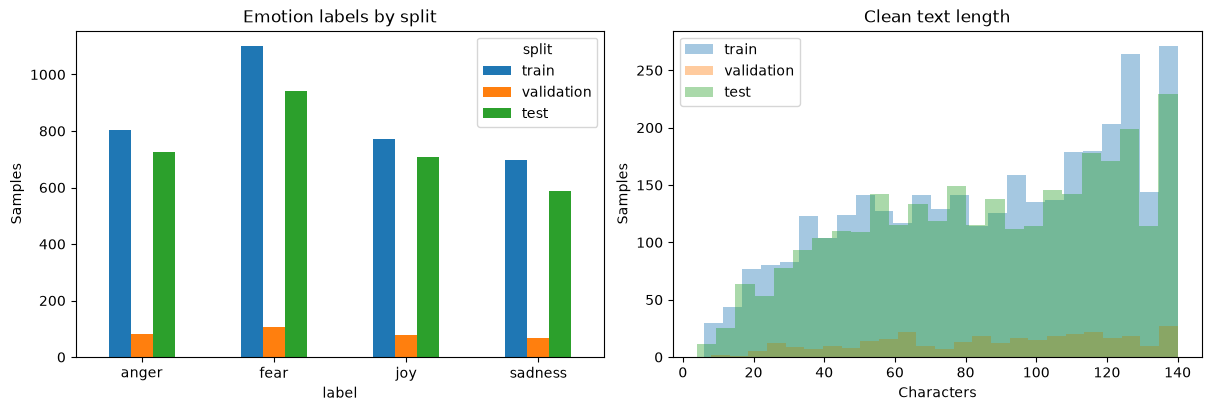

In [4]:
clean_all = pd.concat(clean_frames.values(), ignore_index=True)
label_counts = pd.crosstab(clean_all["label"], clean_all["split"]).reindex(columns=list(DATA_FILES), fill_value=0)
display(label_counts)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
label_counts.plot.bar(ax=axes[0], rot=0)
axes[0].set_title("Emotion labels by split")
axes[0].set_ylabel("Samples")
for split, frame in clean_frames.items():
    axes[1].hist(frame["text"].str.len(), bins=25, alpha=0.4, label=split)
axes[1].set_title("Clean text length")
axes[1].set_xlabel("Characters")
axes[1].set_ylabel("Samples")
axes[1].legend()
plt.show()

## 4. 标签数字化与 DatasetDict

只从训练标签建立稳定的字母排序映射，验证/测试必须使用同一映射。ClassLabel 保存编号与名称。

In [5]:
label_names = sorted(clean_frames["train"]["label"].unique().tolist())
label2id = {label: index for index, label in enumerate(label_names)}
id2label = {index: label for label, index in label2id.items()}
features = Features({"text": Value("string"), "raw_text": Value("string"),
                     "label": ClassLabel(names=label_names), "source_row": Value("int64")})
dataset = DatasetDict()
for split, frame in clean_frames.items():
    assert set(frame["label"]).issubset(label2id), "评估集中有训练集未出现的标签"
    encoded = frame[["text", "raw_text", "label", "source_row"]].copy()
    encoded["label"] = encoded["label"].map(label2id)
    dataset[split] = Dataset.from_pandas(encoded, features=features, preserve_index=False)
print(label2id)
print(dataset)
display(dataset["train"][0])

{'anger': 0, 'fear': 1, 'joy': 2, 'sadness': 3}
DatasetDict({
    train: Dataset({
        features: ['text', 'raw_text', 'label', 'source_row'],
        num_rows: 3373
    })
    validation: Dataset({
        features: ['text', 'raw_text', 'label', 'source_row'],
        num_rows: 330
    })
    test: Dataset({
        features: ['text', 'raw_text', 'label', 'source_row'],
        num_rows: 2963
    })
})


{'text': 'Just got back from seeing in Burslem. AMAZING!! Face still hurts from laughing so much #hilarious',
 'raw_text': 'Just got back from seeing @GaryDelaney in Burslem. AMAZING!! Face still hurts from laughing so much #hilarious',
 'label': 2,
 'source_row': 0}

## 5. XLNet tokenizer 与截断长度

使用 base-cased 对应分词器，保留模型默认特殊 Token 和左侧 padding。只根据训练集的分词长度 95% 分位数选择长度，向上取到 8 的倍数，并受预算上限约束。长度包含特殊 Token。

各集合截断比例用于审计，不用验证/测试长度修改训练参数。

训练集长度 P50/P95/P99：[27.   45.   55.28]；MAX_LENGTH=48
Padding side: left


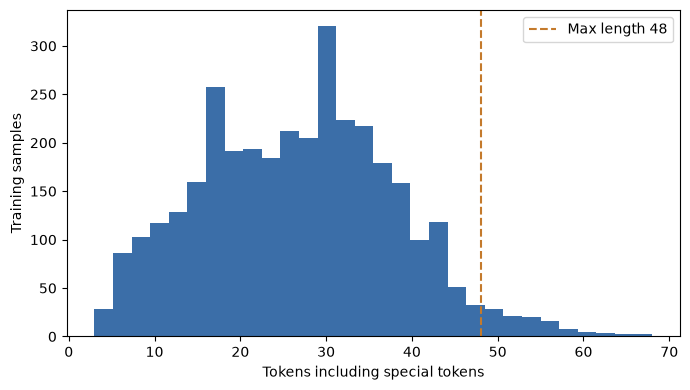

Map:   0%|          | 0/3373 [00:00<?, ? examples/s]

Map:   0%|          | 0/330 [00:00<?, ? examples/s]

Map:   0%|          | 0/2963 [00:00<?, ? examples/s]

,Split,Truncated (%)
0,train,3.201897
1,validation,4.848485
2,test,2.936213


{'text': 'Just got back from seeing in Burslem. AMAZING!! Face still hurts from laughing so much #hilarious',
 'raw_text': 'Just got back from seeing @GaryDelaney in Burslem. AMAZING!! Face still hurts from laughing so much #hilarious',
 'label': 2,
 'source_row': 0,
 'input_ids': [1641,
  345,
  126,
  40,
  2531,
  25,
  3571,
  23,
  12849,
  9,
  8239,
  14338,
  5103,
  7675,
  12274,
  194,
  1990,
  23,
  40,
  9186,
  102,
  178,
  17,
  7967,
  11729,
  617,
  4672,
  4,
  3],
 'attention_mask': [1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1]}

In [6]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
# Dataset 的列对象显式转为 list，兼容 tokenizer 的批量文本接口。
train_lengths = np.array([len(ids) for ids in tokenizer(list(dataset["train"]["text"]), truncation=False)["input_ids"]])
MAX_LENGTH = min(MAX_LENGTH_CAP, max(8, int(np.ceil(np.percentile(train_lengths, 95) / 8) * 8)))
print(f"训练集长度 P50/P95/P99：{np.percentile(train_lengths, [50,95,99])}；MAX_LENGTH={MAX_LENGTH}")
print(f"Padding side: {tokenizer.padding_side}")
plt.figure(figsize=(7, 4))
plt.hist(train_lengths, bins=30, color="#3B6EA8")
plt.axvline(MAX_LENGTH, color="#C47A2C", linestyle="--", label=f"Max length {MAX_LENGTH}")
plt.xlabel("Tokens including special tokens")
plt.ylabel("Training samples")
plt.legend()
plt.tight_layout()
plt.show()

def tokenize_batch(batch):
    """只截断，暂不补齐；padding 留给 DataCollator，减少无用计算。"""
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH)

tokenized_dataset = dataset.map(tokenize_batch, batched=True)
length_audit = []
for split in dataset:
    lengths = [len(ids) for ids in tokenizer(list(dataset[split]["text"]), truncation=False)["input_ids"]]
    length_audit.append({"Split": split, "Truncated (%)": np.mean(np.array(lengths) > MAX_LENGTH) * 100})
display(pd.DataFrame(length_audit))
display(tokenized_dataset["train"][0])

## 6. 动态 padding 与小批次

保留带原文的 Dataset 供检查，另创建只含模型字段的 `model_dataset`。collator 把 `label` 改为模型需要的 `labels`，并按批次最长序列补齐。


In [7]:
model_dataset = tokenized_dataset.remove_columns(["text", "raw_text", "source_row"])
data_collator = DataCollatorWithPadding(tokenizer=tokenizer, return_tensors="pt")
train_loader = DataLoader(model_dataset["train"], batch_size=BATCH_SIZE, shuffle=False, collate_fn=data_collator)
batch = next(iter(train_loader))
print({key: tuple(value.shape) for key, value in batch.items()})
assert batch["input_ids"].shape == batch["attention_mask"].shape
assert batch["labels"].dtype == torch.int64
assert batch["input_ids"].shape[1] <= MAX_LENGTH
assert clean_all["text"].is_unique
for split, path in DATA_FILES.items():
    assert hashlib.sha256(path.read_bytes()).hexdigest() == source_hashes[split]
print("数据、批次和源文件检查通过。")

{'input_ids': (2, 29), 'attention_mask': (2, 29), 'labels': (2,)}
数据、批次和源文件检查通过。


## 7. Embedding 与上下文向量演示

token ID 是整数编号，不是 embedding。预训练 XLNet 的输入嵌入层将 ID 映射为向量，Transformer 再生成上下文向量。

仅对两个训练样本做一次 CPU 推理，关闭梯度和跨批次记忆。不会训练，也不会为全部数据预先保存 embeddings。正式分类微调时模型会自动完成这些计算。

本次验证状态：数据准备已执行；模型权重下载速度较慢，下面的预训练向量演示尚未执行验证。首次运行需要等待下载完成。

微调无需提前计算 embeddings，分类模型会自动完成。默认跳过独立演示；需要时将 RUN_EMBEDDING_DEMO 改为 True。

In [8]:
RUN_EMBEDDING_DEMO = False
if RUN_EMBEDDING_DEMO:
    # 首次会下载约数百 MB 的预训练权重，使用同一 MODEL_NAME 保证词表匹配。
    embedding_model = XLNetModel.from_pretrained(MODEL_NAME)
    embedding_model.eval()
    model_inputs = {key: value for key, value in batch.items() if key != "labels"}
    with torch.no_grad():
        input_embeddings = embedding_model.get_input_embeddings()(batch["input_ids"])
        outputs = embedding_model(**model_inputs, use_mems=False)
        contextual_embeddings = outputs.last_hidden_state
    print("输入词向量 [batch, tokens, hidden]：", tuple(input_embeddings.shape))
    print("上下文向量 [batch, tokens, hidden]：", tuple(contextual_embeddings.shape))
    assert contextual_embeddings.shape == input_embeddings.shape
    assert torch.isfinite(contextual_embeddings).all()
    # 只预览一个非 padding Token 的前 8 个数值；避免打印整个三维张量。
    position = int(batch["attention_mask"][0].nonzero()[0])
    print("Token：", tokenizer.convert_ids_to_tokens(int(batch["input_ids"][0, position])))
    print(contextual_embeddings[0, position, :8])

## 8. 微调配置：完整训练 3 个 epoch

这里的“3 次”指训练集完整遍历 3 轮，不是独立训练 3 个模型。使用全部清洗后的训练集，不冻结 XLNet 主干参数。

训练集用于更新参数；每轮用验证集评估并按 macro-F1 选择最佳 checkpoint；独立测试集不参与选模型。Accuracy 是预测正确的比例，macro-F1 同等重视四个类别。

当前如无 CUDA 将使用 CPU，完整微调可能较慢；不会自动换成小模型或少量样本。首次需下载约 445 MB 权重。
参考：[Hugging Face Trainer](https://huggingface.co/docs/transformers/main_classes/trainer)。

In [9]:
set_seed(SEED)
NUM_EPOCHS = 3
TRAIN_BATCH_SIZE = 4
GRADIENT_ACCUMULATION_STEPS = 4  # 等效批次为 16，减少单次内存占用。
RUN_DIR = Path("xlnet_runs") / datetime.now().strftime("%Y%m%d_%H%M%S_%f")
MODEL_DIR = RUN_DIR / "final_model"
print("设备：", "CUDA" if torch.cuda.is_available() else "CPU")
print("训练样本：", len(model_dataset["train"]), "；epoch：", NUM_EPOCHS)
print("本次结果目录：", RUN_DIR.resolve())

def compute_metrics(eval_prediction):
    """Trainer 传入 logits 和真实标签；argmax 将分类分数转为类别编号。"""
    logits = eval_prediction.predictions
    if isinstance(logits, tuple):
        logits = logits[0]
    predictions = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(eval_prediction.label_ids, predictions),
            "macro_f1": f1_score(eval_prediction.label_ids, predictions,
                                 labels=list(id2label), average="macro", zero_division=0)}

training_args = TrainingArguments(
    output_dir=str(RUN_DIR / "checkpoints"),
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    learning_rate=2e-5, weight_decay=0.01,
    optim="adamw_torch",  # 使用 CPU/CUDA 都支持的普通 AdamW。
    eval_strategy="epoch", save_strategy="epoch",
    load_best_model_at_end=True, metric_for_best_model="macro_f1", greater_is_better=True,
    save_total_limit=2,  # 保留有限 checkpoint；checkpoint 带优化器状态，可用于恢复。
    logging_steps=25, logging_first_step=True,
    report_to="none", push_to_hub=False,  # 只在本机训练和保存，不上传数据或模型。
    seed=SEED, data_seed=SEED,
    dataloader_num_workers=0, dataloader_pin_memory=torch.cuda.is_available(),
    fp16=False, bf16=False,  # 先用全精度，避免硬件精度支持差异。
)

设备： CPU
训练样本： 3373 ；epoch： 3
本次结果目录： D:\Study\AI_Study\Course1_365\34_LLMs使用XLNet进行文本分类\xlnet_runs\20260917_134723_614106


## 9. 加载分类模型并开始训练

预训练 XLNet 提供语言表示，新增的四分类头初始为随机参数，需要通过训练学习情绪标签。加载时关于分类头未初始化的提示属于预期情况。

这一单元格会真正开始训练，请避免重复点击。若中断，可将 `RESUME_CHECKPOINT` 改为已有 checkpoint 文件夹路径；默认从预训练模型开始。

In [10]:
# 如果运行过独立 embedding 演示，先释放其模型和大张量。
for name in ["embedding_model", "outputs", "input_embeddings", "contextual_embeddings"]:
    globals().pop(name, None)
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

classifier = XLNetForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=len(label_names), id2label=id2label, label2id=label2id,
    use_safetensors=False,  # 此官方基础模型提供 PyTorch 权重；保存微调模型时使用默认安全格式。
)
# 各条文本独立分类，不在不相关样本之间传递 XLNet 记忆。
classifier.config.use_mems_train = False
classifier.config.use_mems_eval = False
trainer = Trainer(
    model=classifier, args=training_args,
    train_dataset=model_dataset["train"], eval_dataset=model_dataset["validation"],
    processing_class=tokenizer, data_collator=data_collator, compute_metrics=compute_metrics,
)
RESUME_CHECKPOINT = None
train_result = trainer.train(resume_from_checkpoint=RESUME_CHECKPOINT)
trainer.save_metrics("train", train_result.metrics)
print("完成的 epoch：", trainer.state.epoch)
print("最佳验证 checkpoint：", trainer.state.best_model_checkpoint)
display(pd.DataFrame(trainer.state.log_history))

Loading weights:   0%|          | 0/206 [00:00<?, ?it/s]

[transformers] XLNetForSequenceClassification LOAD REPORT from: xlnet/xlnet-base-cased
Key                             | Status     | 
--------------------------------+------------+-
lm_loss.weight                  | UNEXPECTED | 
lm_loss.bias                    | UNEXPECTED | 
sequence_summary.summary.weight | MISSING    | 
logits_proj.bias                | MISSING    | 
logits_proj.weight              | MISSING    | 
sequence_summary.summary.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors: reconstructing file:   0%|          |  0.00B /  467MB            

model.safetensors: downloading bytes:           |  0.00B            

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,4.113412,0.865098,0.657576,0.651030
2,2.429575,0.611193,0.787879,0.782320
3,1.424244,0.545475,0.812121,0.811931


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

完成的 epoch： 3.0
最佳验证 checkpoint： xlnet_runs\20260917_134723_614106\checkpoints\checkpoint-633


,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_macro_f1,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,5.813638,94.092720,2.000000e-05,0.004739,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,5.549134,56.420849,1.924171e-05,0.118483,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,5.531436,134.685730,1.845182e-05,0.236967,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5.477784,50.050346,1.766193e-05,0.355450,75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5.371147,47.960308,1.687204e-05,0.473934,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.986858,106.004089,1.608215e-05,0.592417,125,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,4.594236,105.449898,1.529226e-05,0.710900,150,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,4.591924,94.865074,1.450237e-05,0.829384,175,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,4.113412,99.835060,1.371248e-05,0.947867,200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,1.000000,211,0.865098,0.657576,0.651030,16.2865,20.262,2.579,NaN,NaN,NaN,NaN,NaN


## 10. 独立测试集：准确率、F1 与混淆矩阵

训练结束后 Trainer 已加载验证集上最佳的模型。测试结果不是训练集准确率，也不用于调整本次模型参数。

,test_loss,test_accuracy,test_macro_f1,test_runtime,test_samples_per_second,test_steps_per_second
0,0.532561,0.825515,0.824637,142.8928,20.736,2.596


              precision    recall  f1-score   support

       anger       0.86      0.79      0.82       724
        fear       0.80      0.84      0.82       942
         joy       0.87      0.86      0.86       708
     sadness       0.78      0.80      0.79       589

    accuracy                           0.83      2963
   macro avg       0.83      0.82      0.82      2963
weighted avg       0.83      0.83      0.83      2963



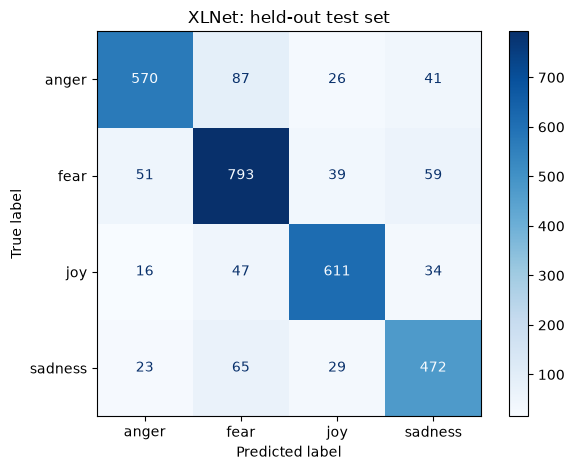

In [11]:
test_result = trainer.predict(model_dataset["test"], metric_key_prefix="test")
test_logits = test_result.predictions
if isinstance(test_logits, tuple):
    test_logits = test_logits[0]
test_predictions = np.argmax(test_logits, axis=-1)
display(pd.DataFrame([test_result.metrics]))
print(classification_report(test_result.label_ids, test_predictions,
                            labels=list(id2label), target_names=label_names, zero_division=0))
ConfusionMatrixDisplay.from_predictions(test_result.label_ids, test_predictions,
    labels=list(id2label), display_labels=label_names, cmap="Blues")
plt.title("XLNet: held-out test set")
plt.tight_layout()
plt.show()
trainer.save_metrics("test", test_result.metrics)

## 11. 保存自定义模型、分词器与预处理规则

`final_model` 保存验证集上最佳模型，而非强制保存最后一轮。每次训练目录独立，不覆盖旧结果。恢复训练使用 `checkpoints`，日常推理使用 `final_model`。

In [12]:
trainer.save_model(str(MODEL_DIR))
tokenizer.save_pretrained(str(MODEL_DIR))
preprocessing_config = {"max_length": MAX_LENGTH, "remove_mentions": True,
    "remove_emoji": True, "lowercase": False, "base_model": MODEL_NAME,
    "label2id": label2id, "seed": SEED}
(MODEL_DIR / "preprocessing_config.json").write_text(
    json.dumps(preprocessing_config, ensure_ascii=False, indent=2), encoding="utf-8")
# 保存清洗函数本身，独立加载模型时不必猜测或重新编写清洗逻辑。
import inspect
(MODEL_DIR / "preprocessing.py").write_text(
    "import re\nfrom cleantext import clean\n\n" + inspect.getsource(clean_for_xlnet), encoding="utf-8")
print("已保存：", MODEL_DIR.resolve())

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

已保存： D:\Study\AI_Study\Course1_365\34_LLMs使用XLNet进行文本分类\xlnet_runs\20260917_134723_614106\final_model


## 12. 从磁盘重新加载并试用

使用保存目录中的模型、分词器和清洗函数，验证保存结果确实可以使用。示例仅供体验，不能代替上面的独立测试指标。置信分数是 softmax 分数，不保证等于实际正确概率。

In [13]:
from importlib.util import spec_from_file_location, module_from_spec

saved_config = json.loads((MODEL_DIR / "preprocessing_config.json").read_text(encoding="utf-8"))
spec = spec_from_file_location("saved_preprocessing", MODEL_DIR / "preprocessing.py")
saved_preprocessing = module_from_spec(spec)
spec.loader.exec_module(saved_preprocessing)
saved_tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR, local_files_only=True)
saved_model = XLNetForSequenceClassification.from_pretrained(MODEL_DIR, local_files_only=True)
saved_model.eval()  # 默认在 CPU 试用，关闭 dropout。

def predict_emotions(texts):
    """输入一条字符串或字符串列表，返回原文、清洗文本、预测情绪及分数。"""
    if isinstance(texts, str):
        texts = [texts]
    cleaned = [saved_preprocessing.clean_for_xlnet(text) for text in texts]
    if not cleaned or any(not text for text in cleaned):
        raise ValueError("请输入清洗后仍有文字内容的文本。")
    inputs = saved_tokenizer(cleaned, padding=True, truncation=True,
        max_length=saved_config["max_length"], return_tensors="pt")
    with torch.no_grad():
        probabilities = saved_model(**inputs).logits.softmax(dim=-1)
    scores, ids = probabilities.max(dim=-1)
    return pd.DataFrame({"text": texts, "clean_text": cleaned,
        "emotion": [saved_model.config.id2label[i] for i in ids.tolist()],
        "confidence": scores.tolist()})

display(predict_emotions([
    "@friend I am so happy and excited about this wonderful news! ❤️",
    "I am furious. This is completely unfair!",
    "I feel lonely and sad. I miss my family.",
    "I am scared and worried about what will happen tomorrow.",
]))

Loading weights:   0%|          | 0/210 [00:00<?, ?it/s]

,text,clean_text,emotion,confidence
0,@friend I am so happy and excited about this w...,I am so happy and excited about this wonderful...,joy,0.991676
1,I am furious. This is completely unfair!,I am furious. This is completely unfair!,anger,0.994162
2,I feel lonely and sad. I miss my family.,I feel lonely and sad. I miss my family.,sadness,0.987902
3,I am scared and worried about what will happen...,I am scared and worried about what will happen...,fear,0.992119
